# Movies Correlation and Key Metrics

**Objective:** Explore the financial and audience-reception metrics of the [Movie Industry dataset](https://www.kaggle.com/datasets/danielgrijalvas/movies) to identify which features (budget, votes, score, etc.) correlate most strongly with box office revenue, and to surface key facts about the highest-performing movies, studios, and actors in the dataset.

**Dataset:** ~7,600 movies (1980s–2020) with budget, gross revenue, runtime, IMDb score, vote count, genre, company, and cast/crew information.

**Workflow:**
1. Data cleaning (missing values, data types, duplicates)
2. Feature engineering (profit, ROI, corrected release year)
3. Correlation analysis (budget vs. revenue, votes vs. revenue)
4. Key metrics (top movies, studios, actors by various measures)
5. Summary of findings

## Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('ggplot')
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 8)  # default plot size for the notebook

## 1. Loading the Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/danielgrijalvas/movies/movies.csv')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [3]:
# Shape and structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [4]:
# Summary statistics for numeric columns
df.describe()

,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


In [5]:
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.columns.tolist()

Rows: 7,668 | Columns: 15


['name',
 'rating',
 'genre',
 'year',
 'released',
 'score',
 'votes',
 'director',
 'writer',
 'star',
 'country',
 'budget',
 'gross',
 'company',
 'runtime']

## 2. Data Cleaning

### 2.1 Missing Values
We first check which columns have missing values, then handle each one based on its type and how many values are missing.

In [6]:
df.isnull().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

**Cleaning strategy:**
- `budget`, `gross`, `runtime`, `score`, `votes` — numeric and right-skewed, so missing values are filled with the **median** (more robust than the mean for skewed financial data).
- `rating` — filled with `'Not Rated'` (77 missing values is too many rows to drop).
- `writer`, `star`, `country`, `company` — filled with `'Unknown'` to preserve the row for numeric analysis.
- `released` — only 2 missing values, so those rows are dropped rather than imputed.

In [7]:
df['budget'] = df['budget'].fillna(df['budget'].median())
df['gross'] = df['gross'].fillna(df['gross'].median())
df['runtime'] = df['runtime'].fillna(df['runtime'].median())
df['score'] = df['score'].fillna(df['score'].median())
df['votes'] = df['votes'].fillna(df['votes'].median())

df['rating'] = df['rating'].fillna('Not Rated')
df['writer'] = df['writer'].fillna('Unknown')
df['star'] = df['star'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['company'] = df['company'].fillna('Unknown')

df = df.dropna(subset=['released'])

# Confirm everything is handled
df.isnull().sum()

name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

### 2.2 Data Types

In [8]:
df['score'] = df['score'].astype('float64')
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')
df['runtime'] = df['runtime'].astype('int64')
df['votes'] = df['votes'].astype('int64')

### 2.3 Fixing the Release Year
The original `year` column doesn't always match the actual release date in the `released` column (e.g. a film listed as `2009` may have actually released in early `2010`). We drop it and extract the correct year directly from `released` instead.

In [9]:
df = df.drop('year', axis=1)
df['release_year'] = df['released'].str.extract(r'(\d{4})').astype('int64')

### 2.4 Removing Duplicate Movies

In [10]:
# Drop rows that are exact duplicates by movie name, keeping the first occurrence
duplicate_count = df.duplicated(subset=['name']).sum()
print(f"Duplicate movie titles found: {duplicate_count}")

df = df.drop_duplicates(subset=['name']).reset_index(drop=True)

Duplicate movie titles found: 156


## 3. Feature Engineering

We add two derived metrics:
- **Profit** = Gross revenue − Budget
- **ROI** (Return on Investment) = Gross revenue / Budget

Before computing ROI, we check for zero-budget rows, since dividing by zero would produce invalid (`inf`) values.

In [11]:
zero_budget = (df['budget'] == 0).sum()
print(f"Movies with $0 budget: {zero_budget}")

df['profit'] = df['gross'] - df['budget']
df['ROI'] = df['gross'] / df['budget']

Movies with $0 budget: 0


## 4. Correlation Analysis

### 4.1 Budget vs. Gross Revenue

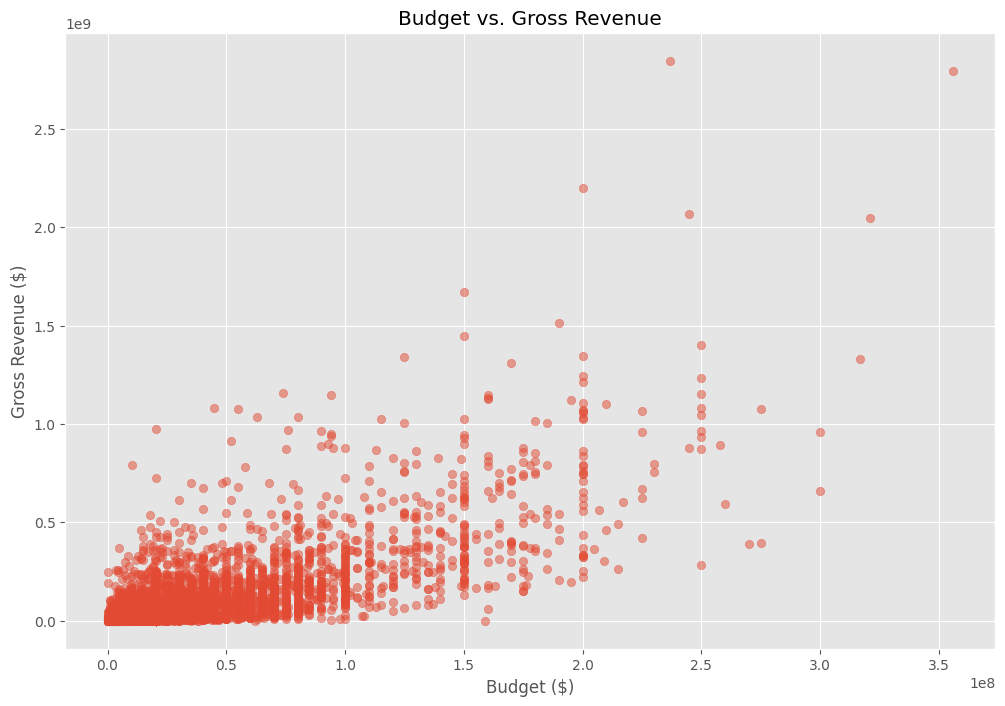

In [12]:
plt.scatter(x=df['budget'], y=df['gross'], alpha=0.5)
plt.title('Budget vs. Gross Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Gross Revenue ($)')
plt.show()

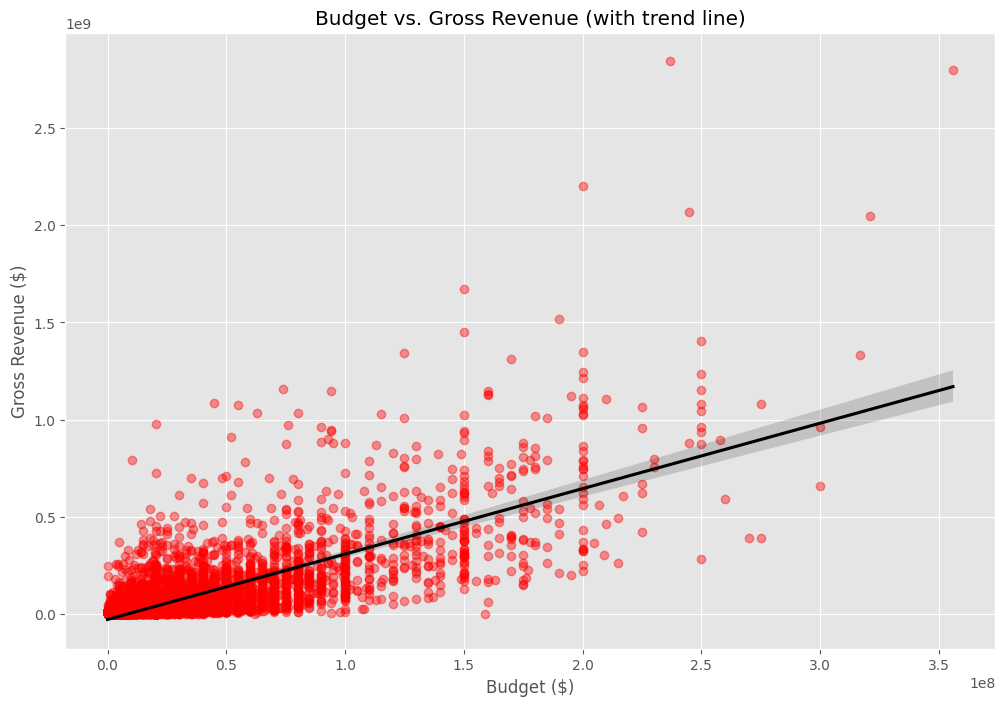

In [13]:
sns.regplot(
    x='budget', y='gross', data=df,
    scatter_kws={"color": "red", "alpha": 0.4},
    line_kws={"color": "black"}
)
plt.title('Budget vs. Gross Revenue (with trend line)')
plt.xlabel('Budget ($)')
plt.ylabel('Gross Revenue ($)')
plt.show()

### 4.2 Correlation Matrix

The numeric correlation matrix below confirms the visual trend: **budget** and **votes** both show a strong positive correlation with **gross revenue**.

In [14]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,score,votes,budget,gross,runtime,release_year,profit,ROI
score,1.000000,0.408442,0.060405,0.185241,0.397784,0.111955,0.202591,-0.015032
votes,0.408442,1.000000,0.457898,0.634425,0.305845,0.219127,0.628458,0.010299
budget,0.060405,0.457898,1.000000,0.744204,0.272195,0.281850,0.616630,-0.025628
gross,0.185241,0.634425,0.744204,1.000000,0.245290,0.250245,0.984746,0.012341
runtime,0.397784,0.305845,0.272195,0.245290,1.000000,0.121599,0.218196,-0.031927
release_year,0.111955,0.219127,0.281850,0.250245,0.121599,1.000000,0.221520,0.011107
profit,0.202591,0.628458,0.616630,0.984746,0.218196,0.221520,1.000000,0.021221
ROI,-0.015032,0.010299,-0.025628,0.012341,-0.031927,0.011107,0.021221,1.000000


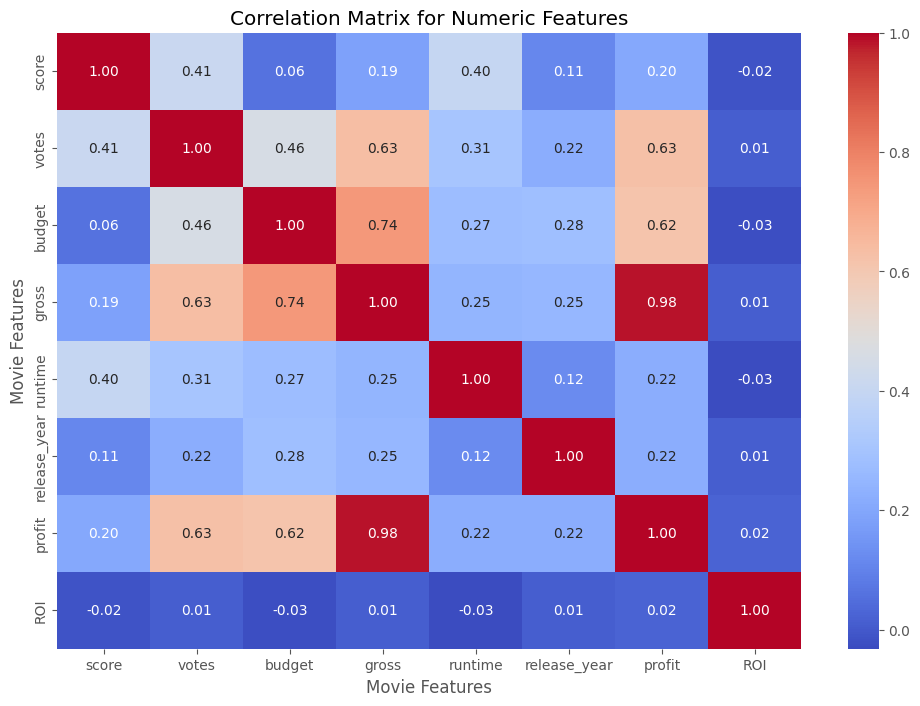

In [15]:
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

## 5. Key Metrics

### 5.1 Top 10 Companies by Total Budget
Total budget, revenue, and profit summed across all movies released by each studio.

In [16]:
df.groupby('company')[['budget', 'gross', 'profit']].sum() \
  .sort_values(by='budget', ascending=False) \
  .head(10)

,budget,gross,profit
company,,,
Warner Bros.,19841300000,55020849867,35179549867
Universal Pictures,16691630001,51550073949,34858443948
Columbia Pictures,15626107000,41522604959,25896497959
Paramount Pictures,14053950000,39318239706,25264289706
Twentieth Century Fox,11875100000,39159651364,27284551364
Walt Disney Pictures,10204700000,33353754158,23149054158
New Line Cinema,5728200000,19020537245,13292337245
Touchstone Pictures,4543200000,11619875640,7076675640
Metro-Goldwyn-Mayer (MGM),3871750000,8604332138,4732582138


### 5.2 Most Prolific Actor

In [17]:
df['star'].value_counts().head(1)

star
Nicolas Cage    42
Name: count, dtype: int64

### 5.3 Highest-Grossing Movie

In [18]:
df.loc[df['gross'].idxmax(), ['name', 'gross', 'star']]

name              Avatar
gross         2847246203
star     Sam Worthington
Name: 5384, dtype: object

### 5.4 Highest-Budget Movie

In [19]:
df.loc[df['budget'].idxmax(), ['name', 'budget', 'star']]

name      Avengers: Endgame
budget            356000000
star      Robert Downey Jr.
Name: 7301, dtype: object

### 5.5 Most-Voted Movie on IMDb

In [20]:
df.loc[df['votes'].idxmax(), ['name', 'votes']]

name     The Shawshank Redemption
votes                     2400000
Name: 2437, dtype: object

### 5.6 Highest-Rated Movie on IMDb

In [21]:
df.loc[df['score'].idxmax(), ['name', 'score']]

name     The Shawshank Redemption
score                         9.3
Name: 2437, dtype: object

### 5.7 Most Profitable Studio (Total Profit)

In [22]:
df.groupby('company')['profit'].sum().sort_values(ascending=False).head(1)

company
Warner Bros.    35179549867
Name: profit, dtype: int64

### 5.8 Studio with the Highest Total ROI

In [23]:
df.groupby('company')['ROI'].sum().sort_values(ascending=False).head(1)

company
Solana Films    12890.386667
Name: ROI, dtype: float64

### 5.9 Most Common Genre per Top Studio
Rather than a nested value count, we pivot this into a clean table: for each of the top 10 studios by movie count, what genre do they make most often?

In [24]:
top_companies = df['company'].value_counts().head(10).index

genre_by_company = (
    df[df['company'].isin(top_companies)]
    .groupby(['company', 'genre'])
    .size()
    .reset_index(name='movie_count')
    .sort_values(['company', 'movie_count'], ascending=[True, False])
)

genre_by_company.loc[genre_by_company.groupby('company')['movie_count'].idxmax()] \
    .sort_values('movie_count', ascending=False) \
    .reset_index(drop=True)

,company,genre,movie_count
0,Universal Pictures,Comedy,132
1,Warner Bros.,Action,125
2,Columbia Pictures,Action,110
3,Paramount Pictures,Comedy,98
4,Twentieth Century Fox,Action,82
5,Touchstone Pictures,Comedy,56
6,New Line Cinema,Comedy,54
7,Metro-Goldwyn-Mayer (MGM),Comedy,45
8,TriStar Pictures,Comedy,38
9,Walt Disney Pictures,Action,31


## 6. Key Findings

- **Budget and votes are the strongest predictors of revenue.** Both show a clear positive correlation with gross box office revenue, while runtime and score have a much weaker relationship.
- Big-budget productions cluster among a small group of major studios, who also account for the highest total profits.
- The highest-grossing, highest-budget, and most-voted movies in the dataset are dominated by blockbuster franchises, reflecting how heavily marketing and production spend influence reach.
- Genre preference varies clearly by studio — most top studios specialize in one or two dominant genres rather than spreading evenly across all of them.

**Possible next steps:** adjust budget/revenue for inflation across decades, segment the correlation analysis by genre, or model revenue as a function of budget, votes, and genre using regression.